## 1. Load Train/Test Split

In [5]:
import pandas as pd

X_train = pd.read_csv("../data/splits/X_train.csv")
X_test = pd.read_csv("../data/splits/X_test.csv")
y_train = pd.read_csv("../data/splits/y_train.csv")
y_test = pd.read_csv("../data/splits/y_test.csv")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (21367, 1)
X_test shape: (5342, 1)
y_train shape: (21367, 1)
y_test shape: (5342, 1)


In [6]:
X_train.head()

,headline
0,fbi raids fridge
1,old el paso introduces emergency taco kit
2,larry kudlow 'leaning' toward senate run in co...
3,"'everything's $10,000' chain goes out of business"
4,what this ceo did proves that introverts make ...


## 2. Feature Engineering

In [7]:
!pip install nltk


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER lexicon once
nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

def count_all_caps(text: str) -> int:
    return sum(1 for word in str(text).split() if word.isupper() and len(word) > 1)

def count_punctuation(text: str, mark: str) -> int:
    return str(text).count(mark)

def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Length-based feature
    df["length"] = df["headline"].apply(len)
    
    # Word count
    df["word_count"] = df["headline"].apply(lambda x: len(str(x).split()))
    
    # Punctuation features
    df["exclamation_count"] = df["headline"].apply(lambda x: count_punctuation(x, "!"))
    df["question_count"] = df["headline"].apply(lambda x: count_punctuation(x, "?"))
    
    # All-caps feature
    df["all_caps_count"] = df["headline"].apply(count_all_caps)
    
    # VADER sentiment
    df["vader_neg"] = df["headline"].apply(lambda x: sia.polarity_scores(str(x))["neg"])
    df["vader_neu"] = df["headline"].apply(lambda x: sia.polarity_scores(str(x))["neu"])
    df["vader_pos"] = df["headline"].apply(lambda x: sia.polarity_scores(str(x))["pos"])
    df["vader_compound"] = df["headline"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
    
    return df

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\denze\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [9]:
# Apply feature engineering to training and test sets to create new numeric features

X_train_fe = feature_engineering(X_train)
X_test_fe = feature_engineering(X_test)

X_train_fe.head()

,headline,length,word_count,exclamation_count,question_count,all_caps_count,vader_neg,vader_neu,vader_pos,vader_compound
0,fbi raids fridge,16,3,0,0,0,0.000,1.000,0.000,0.0000
1,old el paso introduces emergency taco kit,41,7,0,0,0,0.302,0.698,0.000,-0.3818
2,larry kudlow 'leaning' toward senate run in co...,55,8,0,0,0,0.000,1.000,0.000,0.0000
3,"'everything's $10,000' chain goes out of business",49,7,0,0,0,0.000,1.000,0.000,0.0000
4,what this ceo did proves that introverts make ...,59,10,0,0,0,0.000,0.687,0.313,0.6249


# 3.TF-IDF vectorization

In [10]:
# Convert headline text into TF-IDF vectors so the models can use numerical text features

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train["headline"])
X_test_tfidf = tfidf.transform(X_test["headline"])

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (21367, 5000)
X_test_tfidf shape: (5342, 5000)


In [11]:
# Output Check(Expected: rows = number of headlines/columns = number of TF-IDF features, up to 5000

print(type(X_train_tfidf))
print(X_train_tfidf.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(21367, 5000)


## 5. Logistic Regression (TF-IDF Features)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluate
print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy: 0.8341445151628604
Precision: 0.8217909131010146
Recall: 0.794456289978678
F1 Score: 0.8078924544666088


c:\Users\denze\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## 6. Naive Bayes (TF-IDF Features)

In [13]:
from sklearn.naive_bayes import MultinomialNB

# Train model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluate
print("Naive Bayes Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))

Naive Bayes Results:
Accuracy: 0.8255335080494197
Precision: 0.8548468106479156
Recall: 0.7257995735607676
F1 Score: 0.7850553505535055


c:\Users\denze\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## 7. Model Comparison

In [14]:
results = {
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb)
    ]
}

import pandas as pd
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.834145,0.821791,0.794456,0.807892
1,Naive Bayes,0.825534,0.854847,0.725800,0.785055


## 8. Combined TF-IDF and Engineered Features

In [15]:
from scipy.sparse import hstack

numeric_features_train = X_train_fe[[
    "length",
    "exclamation_count",
    "question_count",
    "all_caps_count",
    "vader_compound"
]].values

numeric_features_test = X_test_fe[[
    "length",
    "exclamation_count",
    "question_count",
    "all_caps_count",
    "vader_compound"
]].values

X_train_combined = hstack([X_train_tfidf, numeric_features_train])
X_test_combined = hstack([X_test_tfidf, numeric_features_test])

print(X_train_combined.shape)
print(X_test_combined.shape)

(21367, 5005)
(5342, 5005)


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

lr_model.fit(X_train_combined, y_train)
y_pred_lr_combined = lr_model.predict(X_test_combined)

# Metrics
print("LR Combined Accuracy:", accuracy_score(y_test, y_pred_lr_combined))
print("LR Precision:", precision_score(y_test, y_pred_lr_combined))
print("LR Recall:", recall_score(y_test, y_pred_lr_combined))
print("LR F1 Score:", f1_score(y_test, y_pred_lr_combined))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_combined))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_combined))

c:\Users\denze\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LR Combined Accuracy: 0.8390116061400225
LR Precision: 0.8269484808454426
LR Recall: 0.8008528784648188
LR F1 Score: 0.8136915077989602

Confusion Matrix:
[[2604  393]
 [ 467 1878]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      2997
           1       0.83      0.80      0.81      2345

    accuracy                           0.84      5342
   macro avg       0.84      0.83      0.84      5342
weighted avg       0.84      0.84      0.84      5342



In [17]:
print("\nNB Classification Report:")
print(classification_report(y_test, y_pred_nb))


NB Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85      2997
           1       0.85      0.73      0.79      2345

    accuracy                           0.83      5342
   macro avg       0.83      0.81      0.82      5342
weighted avg       0.83      0.83      0.82      5342



# 9. Error Analysis

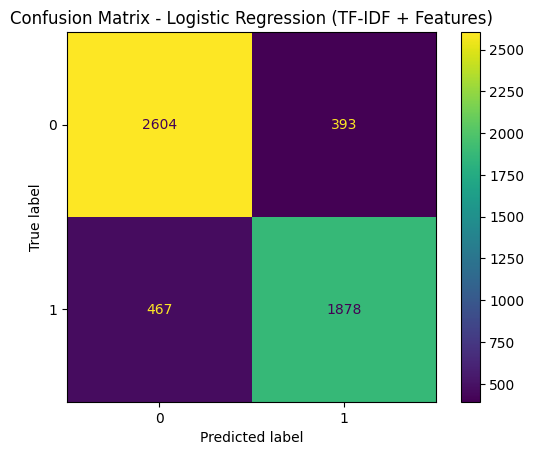

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_combined)
plt.title("Confusion Matrix - Logistic Regression (TF-IDF + Features)")
plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "headline": X_test.iloc[:, 0],
    "actual": y_test.values.ravel(),
    "predicted": y_pred_lr_combined.ravel()
})

misclassified = results[results["actual"] != results["predicted"]]

misclassified.head(10)

,headline,actual,predicted
7,americans finally found something to drink tha...,0,1
8,that show about the lady sheriff finally relea...,1,0
12,letter from employer thankfully omits balls-co...,1,0
23,ladykiller gets life sentence,1,0
32,florida man sentenced for running over ducks w...,0,1
42,trump maps out plan for first 100 days of not ...,1,0
57,apparently reese witherspoon likes j.crew as m...,0,1
66,'fire rainbow' supplants double rainbow as soc...,0,1
76,desperate dolphin mom seen helping her trapped...,0,1
90,will smith: the black man everyone at work can...,1,0


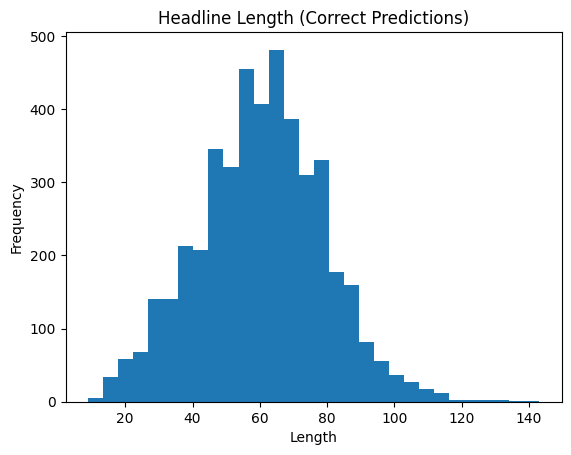

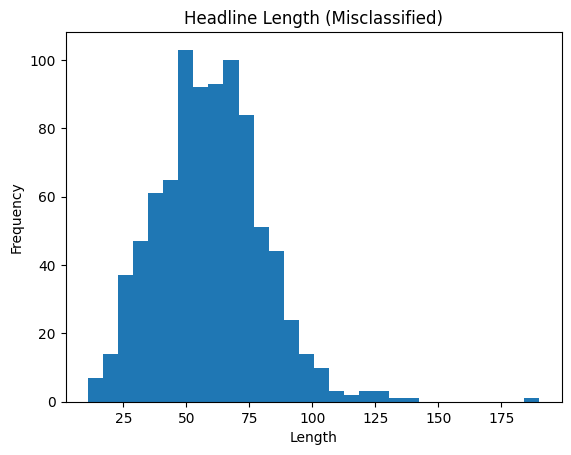

In [ ]:
results["length"] = results["headline"].apply(len)

misclassified = results[results["actual"] != results["predicted"]]

plt.figure()
plt.hist(results[results["actual"] == results["predicted"]]["length"], bins=30)
plt.title("Headline Length (Correct Predictions)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(misclassified["length"], bins=30)
plt.title("Headline Length (Misclassified)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()